# Sigma Discrepancy Diagnostic

**Problem:** Notebook 01 gives sigma ~308 km/s (integrated, 190-spaxel box).
Notebook 05 gives sigma ~204-226 km/s (radial bins, circular aperture).

**Goal:** Isolate the cause by running both methods on the same and different
spaxel selections, checking each step for consistency.

**Tests:**
1. Run NB05's `ppxf_radial_bin` on NB01's exact 190 spaxels → does sigma match NB01?
2. Run NB01's exact procedure on NB05's central 9 spaxels → does sigma match NB05?
3. Check if the spaxel averaging produces the same spectrum
4. Test sigma sensitivity to polynomial degree at different S/N
5. Check for lensed arc contamination in different spatial regions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from time import perf_counter as clock
from importlib import resources
from urllib import request
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=14)

# Load the IFU cube
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
with fits.open(ifu_file) as hdul:
    hdr = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

crval = hdr['CRVAL3']
cdelt = hdr['CD3_3']
npix = hdr['NAXIS3']
crpix = hdr.get('CRPIX3', 1.0)
pix = np.arange(npix)
lam = crval + cdelt * (pix + 1 - crpix)

print(f'Cube: {cube.shape}, wavelength: {lam[0]:.0f}-{lam[-1]:.0f} Å')

Cube: (3317, 100, 100), wavelength: 5625-8941 Å


## Test 1: NB01 procedure exactly reproduced

In [2]:
# ===== EXACT NB01 PROCEDURE (copy-pasted from cells 8e8bae4a + a30f240b + eda6879e) =====

# Step A: Extract spectrum (cell 8e8bae4a)
flux_int_01 = np.average(cube[:, 45:64, 45:55], axis=(1, 2))
noise_int_01 = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
lam_int_01 = crval + cdelt * (pix + 1 - crpix)

mask_wl = (lam_int_01 >= 6500.0) & (lam_int_01 <= 7500.0)
lam_int_01 = lam_int_01[mask_wl]
flux_int_01 = flux_int_01[mask_wl]
noise_int_01 = noise_int_01[mask_wl]

z_01 = 0.67511

log_lam = np.log(lam_int_01)
d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam_int_01) - 1)
log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
flux_int_01 = np.interp(log_lam_new, log_lam, flux_int_01)
noise_int_01 = np.interp(log_lam_new, log_lam, noise_int_01)
lam_int_01 = np.exp(log_lam_new)

mask_fit = (lam_int_01 >= 6000.0) & (lam_int_01 <= 7500.0)
lam_int_01 = lam_int_01[mask_fit]
flux_int_01 = flux_int_01[mask_fit]
noise_int_01 = noise_int_01[mask_fit]

# Step B: Setup (cell a30f240b)
galaxy_01 = flux_int_01 / np.median(flux_int_01)
lam_gal_01 = np.copy(lam_int_01)
lam_gal_01 *= np.median(util.vac_to_air(lam_gal_01) / lam_gal_01)

c_kms = 299792.458
d_ln = (np.log(lam_gal_01)[-1] - np.log(lam_gal_01)[0]) / (np.log(lam_gal_01).size - 1)
velscale_01 = c_kms * d_ln

sps_name = 'fsps'
ppxf_dir = resources.files('ppxf')
filename = ppxf_dir / 'sps_models' / f'spectra_{sps_name}_9.0.npz'

dlam = np.gradient(lam_gal_01)
wdisp = hdr['DISPSCAL']
fwhm_gal = 2.355 * wdisp * dlam

lam_rest_01 = lam_gal_01 / (1 + z_01)
fwhm_rest_01 = fwhm_gal / (1 + z_01)
fwhm_dict = {'lam': lam_rest_01, 'fwhm': fwhm_rest_01}

sps_01 = lib.sps_lib(filename, velscale_01, fwhm_dict, lam_range=[3500, 5000])
goodpix_01 = util.determine_goodpixels(np.log(lam_rest_01), [3500, 5000])

print(f'NB01 procedure: npix={len(galaxy_01)}, good={len(goodpix_01)}, velscale={velscale_01:.2f}')
print(f'  median(flux_int) = {np.median(flux_int_01):.4f}')
print(f'  median(noise_int) = {np.median(noise_int_01):.6f}')
print(f'  noise/galaxy ratio: {np.median(noise_int_01)/np.median(galaxy_01):.4f}')
print(f'  NB01 passes UNNORMALIZED noise: noise_int ~ {np.median(noise_int_01):.6f}')
print(f'  If normalized: noise/median(flux) ~ {np.median(noise_int_01)/np.median(flux_int_01):.6f}')

# Step C: ppxf at degree 20 (cell eda6879e)
pp_01 = ppxf(sps_01.templates, galaxy_01, np.sqrt(noise_int_01**2), velscale_01, [0, 300.],
             goodpixels=goodpix_01, plot=False, moments=2, trig=False,
             degree=20, lam=lam_rest_01, lam_temp=sps_01.lam_temp, mdegree=0)
print(f'\nNB01 result (degree=20, FSPS):')
print(f'  sigma = {pp_01.sol[1]:.1f} km/s')
print(f'  V = {pp_01.sol[0]:.1f} km/s')
print(f'  chi2/DOF = {pp_01.chi2:.2f}')

NB01 procedure: npix=1001, good=927, velscale=42.90
  median(flux_int) = 0.0086
  median(noise_int) = 0.003056
  noise/galaxy ratio: 0.0031
  NB01 passes UNNORMALIZED noise: noise_int ~ 0.003056
  If normalized: noise/median(flux) ~ 0.353536
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387

NB01 result (degree=20, FSPS):
  sigma = 303.9 km/s
  V = 4.1 km/s
  chi2/DOF = 538.52


/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

## Test 2: NB05 procedure on the SAME 190 spaxels

In [3]:
# ===== NB05 ppxf_radial_bin on the same 190 spaxels =====
# Average the same box: cube[:, 45:64, 45:55]
flux_box = np.average(cube[:, 45:64, 45:55], axis=(1, 2))  # same as NB01
noise_sky = np.std(cube[:, 28:40, 45:70], axis=(1, 2))     # same noise

# NB05 procedure: trim 6500-7500 first, then log-rebin
mask_wl = (lam >= 6500.0) & (lam <= 7500.0)
lam_trim = lam[mask_wl]
flux_trim = flux_box[mask_wl]
noise_trim = noise_sky[mask_wl]

log_lam = np.log(lam_trim)
d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam_trim) - 1)
log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
flux_05 = np.interp(log_lam_new, log_lam, flux_trim)
noise_05 = np.interp(log_lam_new, log_lam, noise_trim)
lam_05 = np.exp(log_lam_new)

mask_fit = (lam_05 >= 6000.0) & (lam_05 <= 7500.0)
lam_05 = lam_05[mask_fit]
flux_05 = flux_05[mask_fit]
noise_05 = noise_05[mask_fit]

# Normalize (NB05 style — both galaxy and noise normalized)
galaxy_05 = flux_05 / np.median(flux_05)
noise_norm_05 = np.sqrt(noise_05**2) / np.median(flux_05)

lam_gal_05 = np.copy(lam_05)
lam_gal_05 *= np.median(util.vac_to_air(lam_gal_05) / lam_gal_05)

d_ln = (np.log(lam_gal_05)[-1] - np.log(lam_gal_05)[0]) / (len(lam_gal_05) - 1)
velscale_05 = c_kms * d_ln

lam_rest_05 = lam_gal_05 / (1 + 0.67511)
fwhm_05 = 2.355 * hdr['DISPSCAL'] * np.gradient(lam_gal_05) / (1 + 0.67511)
fwhm_dict_05 = {'lam': lam_rest_05, 'fwhm': fwhm_05}

sps_05 = lib.sps_lib(filename, velscale_05, fwhm_dict_05, lam_range=[3500, 5000])
goodpix_05 = util.determine_goodpixels(np.log(lam_rest_05), [3500, 5000])

print(f'NB05 procedure on SAME 190 spaxels: npix={len(galaxy_05)}, good={len(goodpix_05)}, velscale={velscale_05:.2f}')
print(f'  noise_norm median: {np.median(noise_norm_05):.6f}')

# ppxf with NORMALIZED noise (NB05 style)
pp_05_norm = ppxf(sps_05.templates, galaxy_05, noise_norm_05, velscale_05, [0, 300.],
                  goodpixels=goodpix_05, plot=False, moments=2, trig=False,
                  degree=20, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
print(f'\nNB05 procedure, NORMALIZED noise, degree=20:')
print(f'  sigma = {pp_05_norm.sol[1]:.1f} km/s')
print(f'  V = {pp_05_norm.sol[0]:.1f} km/s')
print(f'  chi2/DOF = {pp_05_norm.chi2:.2f}')

# ppxf with UNNORMALIZED noise (NB01 style) on same spectrum
pp_05_unnorm = ppxf(sps_05.templates, galaxy_05, np.sqrt(noise_05**2), velscale_05, [0, 300.],
                    goodpixels=goodpix_05, plot=False, moments=2, trig=False,
                    degree=20, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
print(f'\nNB05 procedure, UNNORMALIZED noise (NB01 style), degree=20:')
print(f'  sigma = {pp_05_unnorm.sol[1]:.1f} km/s')
print(f'  V = {pp_05_unnorm.sol[0]:.1f} km/s')
print(f'  chi2/DOF = {pp_05_unnorm.chi2:.2f}')

NB05 procedure on SAME 190 spaxels: npix=1001, good=927, velscale=42.90
  noise_norm median: 0.353536
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 0.04023; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387

NB05 procedure, NORMALIZED noise, degree=20:
  sigma = 303.9 km/s
  V = 4.1 km/s
  chi2/DOF = 0.04
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387

NB05 procedure, UNNORMALIZED noise (NB01 style), degree=20:
  sigma = 303.9 km/s
  V = 4.1 km/s
  chi2/DOF = 538.52


## Test 3: Are the spectra actually the same?

NB01 galaxy: shape=(1001,), median=1.0000, std=0.1465
NB05 galaxy: shape=(1001,), median=1.0000, std=0.1465
Same shape: True
Max |diff|: 0.000000
RMS diff: 0.000000
Spectra identical: True


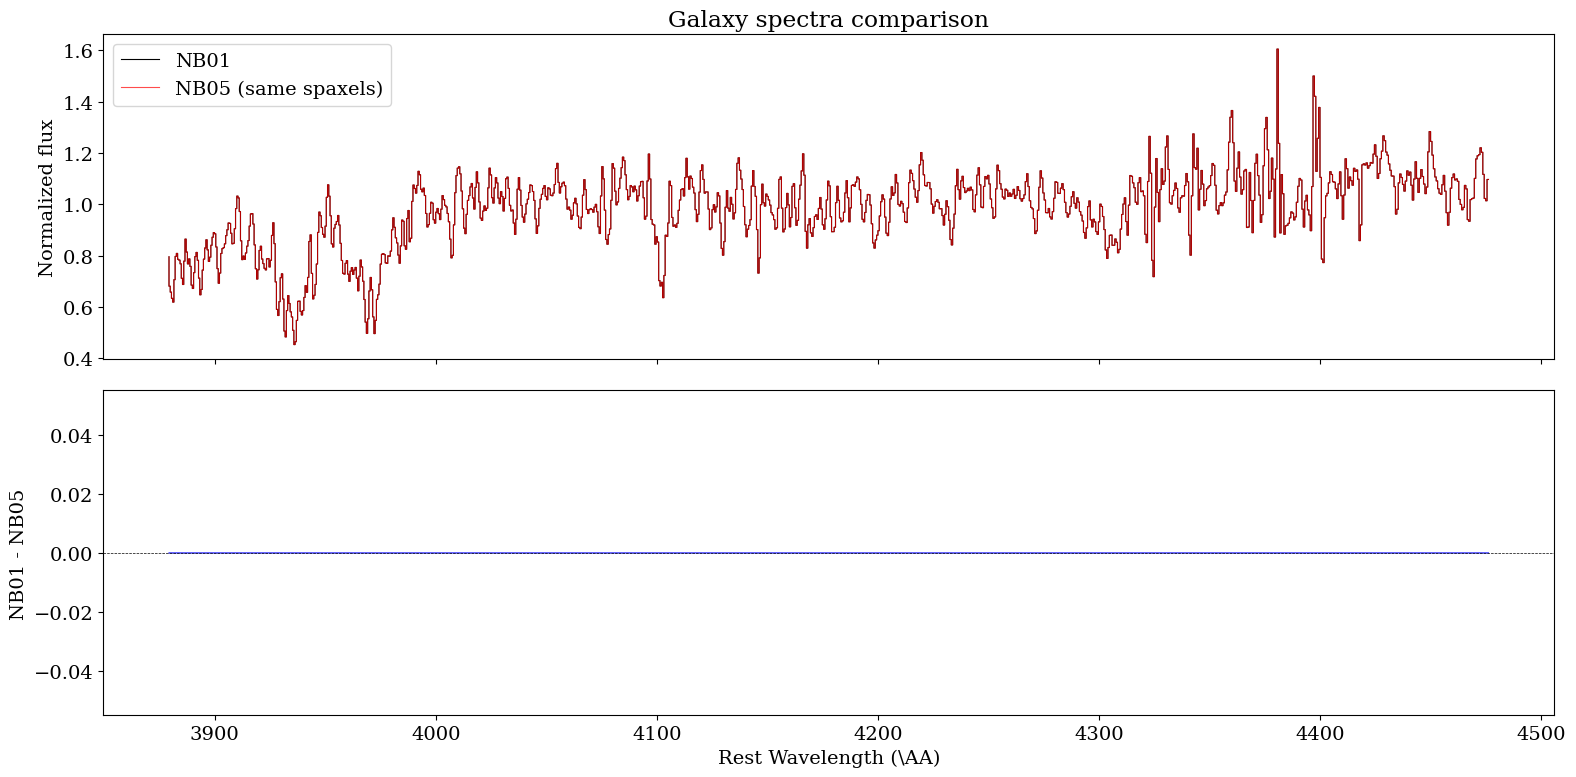

In [4]:
# Compare the galaxy spectra from both procedures
print(f'NB01 galaxy: shape={galaxy_01.shape}, median={np.median(galaxy_01):.4f}, std={np.std(galaxy_01):.4f}')
print(f'NB05 galaxy: shape={galaxy_05.shape}, median={np.median(galaxy_05):.4f}, std={np.std(galaxy_05):.4f}')
print(f'Same shape: {galaxy_01.shape == galaxy_05.shape}')

if galaxy_01.shape == galaxy_05.shape:
    diff = galaxy_01 - galaxy_05
    print(f'Max |diff|: {np.max(np.abs(diff)):.6f}')
    print(f'RMS diff: {np.sqrt(np.mean(diff**2)):.6f}')
    print(f'Spectra identical: {np.allclose(galaxy_01, galaxy_05, atol=1e-10)}')

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].step(lam_rest_01, galaxy_01, 'k', lw=0.8, label='NB01')
axes[0].step(lam_rest_05, galaxy_05, 'r', lw=0.8, alpha=0.7, label='NB05 (same spaxels)')
axes[0].set_ylabel('Normalized flux')
axes[0].legend()
axes[0].set_title('Galaxy spectra comparison')

if galaxy_01.shape == galaxy_05.shape:
    axes[1].step(lam_rest_01, diff, 'b', lw=0.8)
    axes[1].axhline(0, color='k', ls='--', lw=0.5)
    axes[1].set_ylabel('NB01 - NB05')
    axes[1].set_xlabel(r'Rest Wavelength (\AA)')
else:
    axes[1].step(lam_rest_01, galaxy_01, 'k', lw=0.8, label='NB01')
    axes[1].step(lam_rest_05, galaxy_05, 'r', lw=0.8, label='NB05')
    axes[1].set_xlabel(r'Rest Wavelength (\AA)')
    axes[1].legend()

plt.tight_layout()
plt.show()

## Test 4: Degree sweep comparison

 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 567.7; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 0.04241; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 567.7; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       273
chi2/DOF: 567.6; DOF: 925; degree = 1; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       273
chi2/DOF: 0.04240; DOF: 925;

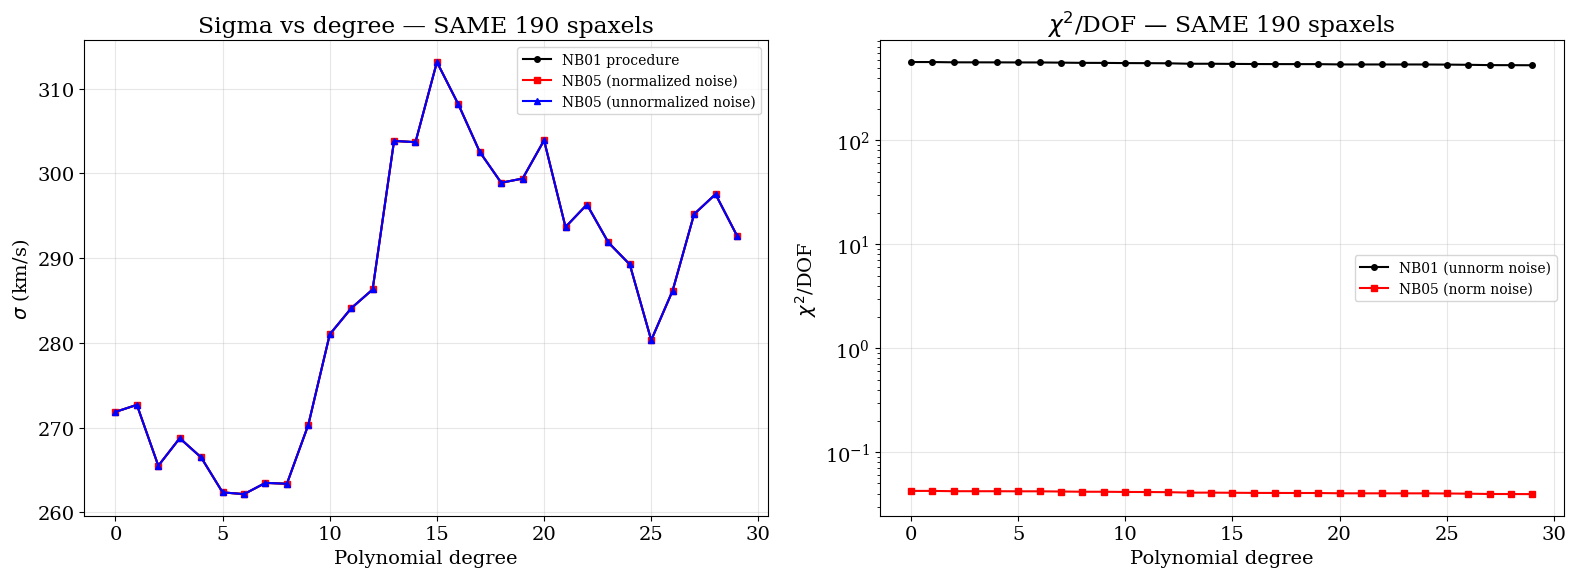


At degree=20:
  NB01: sigma=303.9, chi2=538.52
  NB05 norm: sigma=303.9, chi2=0.04
  NB05 unnorm: sigma=303.9
  Max |sigma diff| across all degrees: 0.0 km/s


In [5]:
# Run ppxf at all degrees 0-29 on the same 190 spaxels,
# with both NB01 (unnormalized noise) and NB05 (normalized noise) approaches

degrees = np.arange(0, 30)
sigma_01_sweep = np.zeros(len(degrees))
sigma_05_norm_sweep = np.zeros(len(degrees))
sigma_05_unnorm_sweep = np.zeros(len(degrees))
chi2_01 = np.zeros(len(degrees))
chi2_05_norm = np.zeros(len(degrees))

for c, deg in enumerate(degrees):
    # NB01 style
    pp = ppxf(sps_01.templates, galaxy_01, np.sqrt(noise_int_01**2), velscale_01, [0, 300.],
              goodpixels=goodpix_01, plot=False, moments=2, trig=False,
              degree=deg, lam=lam_rest_01, lam_temp=sps_01.lam_temp, mdegree=0)
    sigma_01_sweep[c] = pp.sol[1]
    chi2_01[c] = pp.chi2
    
    # NB05 style, normalized noise
    pp = ppxf(sps_05.templates, galaxy_05, noise_norm_05, velscale_05, [0, 300.],
              goodpixels=goodpix_05, plot=False, moments=2, trig=False,
              degree=deg, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
    sigma_05_norm_sweep[c] = pp.sol[1]
    chi2_05_norm[c] = pp.chi2
    
    # NB05 style, unnormalized noise (same as NB01)
    pp = ppxf(sps_05.templates, galaxy_05, np.sqrt(noise_05**2), velscale_05, [0, 300.],
              goodpixels=goodpix_05, plot=False, moments=2, trig=False,
              degree=deg, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
    sigma_05_unnorm_sweep[c] = pp.sol[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(degrees, sigma_01_sweep, 'k-o', markersize=4, label='NB01 procedure')
ax.plot(degrees, sigma_05_norm_sweep, 'r-s', markersize=4, label='NB05 (normalized noise)')
ax.plot(degrees, sigma_05_unnorm_sweep, 'b-^', markersize=4, label='NB05 (unnormalized noise)')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title('Sigma vs degree — SAME 190 spaxels')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(degrees, chi2_01, 'k-o', markersize=4, label='NB01 (unnorm noise)')
ax.plot(degrees, chi2_05_norm, 'r-s', markersize=4, label='NB05 (norm noise)')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel(r'$\chi^2$/DOF')
ax.set_title(r'$\chi^2$/DOF — SAME 190 spaxels')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nAt degree=20:')
print(f'  NB01: sigma={sigma_01_sweep[20]:.1f}, chi2={chi2_01[20]:.2f}')
print(f'  NB05 norm: sigma={sigma_05_norm_sweep[20]:.1f}, chi2={chi2_05_norm[20]:.2f}')
print(f'  NB05 unnorm: sigma={sigma_05_unnorm_sweep[20]:.1f}')
print(f'  Max |sigma diff| across all degrees: {np.max(np.abs(sigma_01_sweep - sigma_05_norm_sweep)):.1f} km/s')

## Test 5: Central spaxels vs full box

In [6]:
# Compare sigma for different spatial selections
# All using the NB01 procedure to isolate spatial effects

from scipy.ndimage import gaussian_filter
wcs_ifu = WCS(hdr, naxis=2)

# White-light peak for centering
wl = np.sum(cube[:, 35:75, 30:70], axis=0)
wl_smooth = gaussian_filter(wl, sigma=2)
dy, dx = np.unravel_index(np.argmax(wl_smooth), wl_smooth.shape)
cy, cx = 35 + dy, 30 + dx
print(f'White-light peak: ({cx}, {cy})')

# Define spatial selections
selections = {
    'NB01 box [45:64, 45:55]': (slice(45,64), slice(45,55)),
    'Center 3x3 around peak': (slice(cy-1,cy+2), slice(cx-1,cx+2)),
    'Center 5x5 around peak': (slice(cy-2,cy+3), slice(cx-2,cx+3)),
    'Center 7x7 around peak': (slice(cy-3,cy+4), slice(cx-3,cx+4)),
    'Center 11x11 around peak': (slice(cy-5,cy+6), slice(cx-5,cx+6)),
    'Wide 20x20 around peak': (slice(cy-10,cy+10), slice(cx-10,cx+10)),
}

print(f'\n{"Selection":<30} {"N_spax":>7} {"sigma_d15":>9} {"sigma_d20":>9} {"sigma_d25":>9} {"chi2_d20":>9}')
print('-' * 75)

for name, (ysl, xsl) in selections.items():
    flux = np.average(cube[:, ysl, xsl], axis=(1, 2))
    n_spax = (ysl.stop - ysl.start) * (xsl.stop - xsl.start)
    
    # NB01-style prep
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t, flux, noise = lam_t[m], flux[m], noise[m]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    flux = np.interp(lln, ll, flux)
    noise = np.interp(lln, ll, noise)
    lam_t = np.exp(lln)
    m2 = (lam_t >= 6000) & (lam_t <= 7500)
    lam_t, flux, noise = lam_t[m2], flux[m2], noise[m2]
    
    gal = flux / np.median(flux)
    lg = np.copy(lam_t)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr['DISPSCAL'] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {'lam': lr, 'fwhm': fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    
    sigmas = []
    chi2_val = None
    for deg in [15, 20, 25]:
        pp = ppxf(sp.templates, gal, np.sqrt(noise**2), vs, [0, 300.],
                  goodpixels=gp, plot=False, moments=2, trig=False,
                  degree=deg, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
        sigmas.append(pp.sol[1])
        if deg == 20:
            chi2_val = pp.chi2
    
    print(f'{name:<30} {n_spax:7d} {sigmas[0]:9.1f} {sigmas[1]:9.1f} {sigmas[2]:9.1f} {chi2_val:9.2f}')

White-light peak: (50, 55)

Selection                       N_spax sigma_d15 sigma_d20 sigma_d25  chi2_d20
---------------------------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:        10       313
chi2/DOF: 544.7; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       -14       280
chi2/DOF: 536.3; DOF: 925; degree = 25; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
NB01 box [45:64, 45:55]            190     313.1     303.9     280.3    538.52
 Best Fit:       Vel     sigma
 comp.  0:        -5   

## Test 6: Spatial contamination check

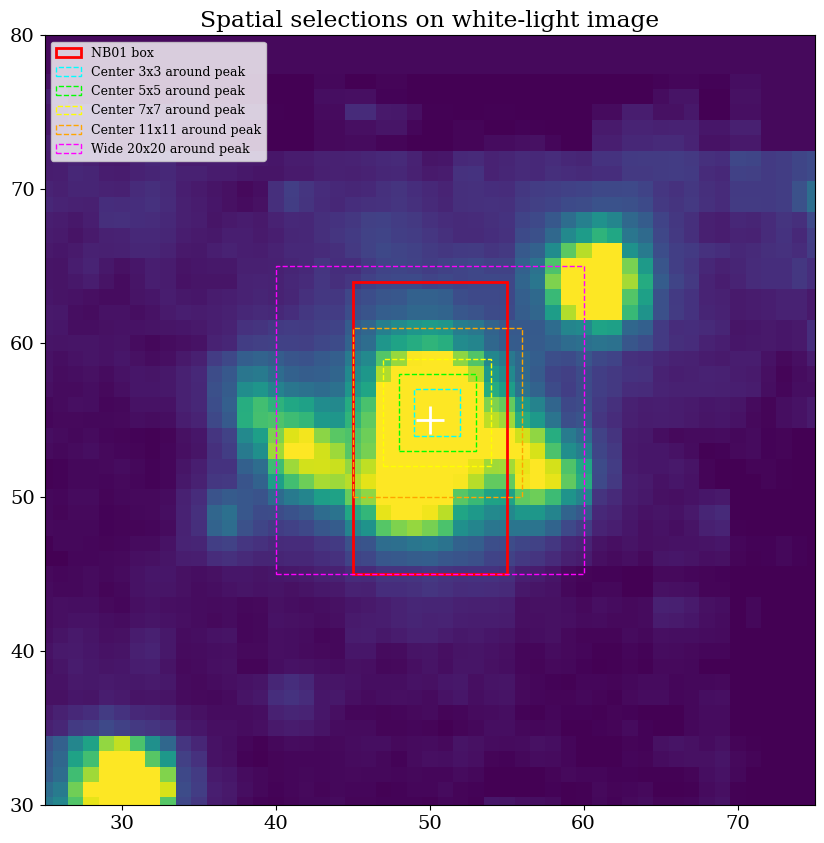

The NB01 box center is at (50, 54.5) — is this the galaxy center?
White-light peak is at (50, 55)
Offset: dx=0, dy=0.5


In [7]:
# Show the white-light image with all spatial selections overlaid
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 10))
wl_full = np.sum(cube, axis=0)
ax.imshow(wl_full, origin='lower', cmap='viridis',
          vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))

# NB01 box
ax.add_patch(Rectangle((45, 45), 10, 19, edgecolor='red', facecolor='none', lw=2, label='NB01 box'))
# White-light peak
ax.plot(cx, cy, 'w+', markersize=20, markeredgewidth=2)
# Center selections
colors = ['cyan', 'lime', 'yellow', 'orange', 'magenta']
for (name, (ysl, xsl)), color in zip(list(selections.items())[1:], colors):
    w = xsl.stop - xsl.start
    h = ysl.stop - ysl.start
    ax.add_patch(Rectangle((xsl.start, ysl.start), w, h,
                           edgecolor=color, facecolor='none', lw=1, ls='--', label=name))

ax.set_xlim(25, 75)
ax.set_ylim(30, 80)
ax.set_title('Spatial selections on white-light image')
ax.legend(fontsize=9, loc='upper left')
plt.show()

print('The NB01 box center is at (50, 54.5) — is this the galaxy center?')
print(f'White-light peak is at ({cx}, {cy})')
print(f'Offset: dx={cx-50}, dy={cy-54.5}')

## Test 7: Apply source mask from HST photometry

Load the F140W mask (which excludes the lensed arc and contaminants),
reproject it onto the IFU spaxel grid, and re-run the spatial selections
with contaminated spaxels excluded.

In [ ]:
# Load HST F140W mask and cutout
mask_file = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits'
cutout_file = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'

mask_hst = fits.getdata(mask_file).astype(bool)
hdr_cutout = fits.getheader(cutout_file)
wcs_cutout = WCS(hdr_cutout)

print(f'HST mask shape: {mask_hst.shape}')
print(f'Masked pixels: {np.sum(mask_hst)} / {mask_hst.size} ({100*np.sum(mask_hst)/mask_hst.size:.1f}%)')

# Show the mask
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
img_cutout = fits.getdata(cutout_file)
axes[0].imshow(img_cutout, origin='lower', cmap='viridis',
               vmin=np.nanpercentile(img_cutout, 1), vmax=np.nanpercentile(img_cutout, 99))
axes[0].set_title('F140W cutout')
axes[1].imshow(mask_hst.astype(float), origin='lower', cmap='Reds')
axes[1].set_title('Mask (red = excluded)')
plt.tight_layout()
plt.show()


In [ ]:
# Reproject the HST mask onto the IFU spaxel grid
# For each IFU spaxel, check if its RA/Dec falls on a masked HST pixel

wcs_ifu = WCS(hdr, naxis=2)

# Build IFU spaxel grid (full 100x100)
yy_ifu, xx_ifu = np.mgrid[0:100, 0:100]
ra_ifu, dec_ifu = wcs_ifu.pixel_to_world_values(xx_ifu.ravel(), yy_ifu.ravel())
ra_ifu = ra_ifu.reshape(100, 100)
dec_ifu = dec_ifu.reshape(100, 100)

# Convert IFU RA/Dec to HST pixel coordinates
x_hst, y_hst = wcs_cutout.world_to_pixel_values(ra_ifu.ravel(), dec_ifu.ravel())
x_hst = x_hst.reshape(100, 100)
y_hst = y_hst.reshape(100, 100)

# For each IFU spaxel, check if it falls on a masked HST pixel
spaxel_masked = np.zeros((100, 100), dtype=bool)
for iy in range(100):
    for ix in range(100):
        hx = int(round(x_hst[iy, ix]))
        hy = int(round(y_hst[iy, ix]))
        if 0 <= hy < mask_hst.shape[0] and 0 <= hx < mask_hst.shape[1]:
            # Also check surrounding HST pixels (IFU spaxel is ~0.3 arcsec = ~4 HST pixels)
            r = 2  # check 5x5 HST pixel box
            hy0 = max(0, hy-r)
            hy1 = min(mask_hst.shape[0], hy+r+1)
            hx0 = max(0, hx-r)
            hx1 = min(mask_hst.shape[1], hx+r+1)
            # If ANY HST pixel in the box is masked, flag this spaxel
            if np.any(mask_hst[hy0:hy1, hx0:hx1]):
                spaxel_masked[iy, ix] = True

print(f'IFU spaxels masked: {np.sum(spaxel_masked)} / {100*100}')

# Show masked spaxels overlaid on white-light
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wl_full = np.sum(cube, axis=0)
axes[0].imshow(wl_full, origin='lower', cmap='viridis',
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[0].imshow(np.where(spaxel_masked, 1, np.nan), origin='lower', cmap='Reds', alpha=0.4)
axes[0].set_title('IFU white-light + masked spaxels (red)')
axes[0].set_xlim(25, 75)
axes[0].set_ylim(30, 80)

# Zoom on deflector region
axes[1].imshow(wl_full[35:75, 30:70], origin='lower', cmap='viridis',
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[1].imshow(np.where(spaxel_masked[35:75, 30:70], 1, np.nan),
               origin='lower', cmap='Reds', alpha=0.5)
axes[1].set_title('Zoomed: masked spaxels on deflector region')

plt.tight_layout()
plt.show()


## Test 8: Sigma with source masking applied

In [ ]:
# Re-run the spatial selection test but EXCLUDING masked spaxels
print('Sigma with source masking (contaminated spaxels excluded):')
print(f"{'Selection':<35} {'N_total':>7} {'N_clean':>7} {'sigma_d15':>9} {'sigma_d20':>9} {'sigma_d25':>9}")
print('-' * 80)

results_masked = []
for name, (ysl, xsl) in selections.items():
    n_total = (ysl.stop - ysl.start) * (xsl.stop - xsl.start)
    
    # Get clean (unmasked) spaxels in this region
    region_mask = spaxel_masked[ysl, xsl]
    clean = ~region_mask
    n_clean = np.sum(clean)
    
    if n_clean < 3:
        print(f'{name:<35} {n_total:7d} {n_clean:7d}   (too few clean spaxels)')
        continue
    
    # Average only the CLEAN spaxels
    sub_cube = cube[:, ysl, xsl]
    flux_clean = np.average(sub_cube[:, clean], axis=1)
    
    # Same NB01-style prep
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t, flux_c, noise_c = lam_t[m], flux_clean[m], noise[m]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    flux_c = np.interp(lln, ll, flux_c)
    noise_c = np.interp(lln, ll, noise_c)
    lam_t = np.exp(lln)
    m2 = (lam_t >= 6000) & (lam_t <= 7500)
    lam_t, flux_c, noise_c = lam_t[m2], flux_c[m2], noise_c[m2]
    
    gal = flux_c / np.median(flux_c)
    lg = np.copy(lam_t)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr['DISPSCAL'] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {'lam': lr, 'fwhm': fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    
    sigmas = []
    for deg in [15, 20, 25]:
        pp = ppxf(sp.templates, gal, np.sqrt(noise_c**2), vs, [0, 300.],
                  goodpixels=gp, plot=False, moments=2, trig=False,
                  degree=deg, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
        sigmas.append(pp.sol[1])
    
    print(f'{name:<35} {n_total:7d} {n_clean:7d} {sigmas[0]:9.1f} {sigmas[1]:9.1f} {sigmas[2]:9.1f}')
    results_masked.append({'name': name, 'n_total': n_total, 'n_clean': n_clean, 'sigmas': sigmas})


In [ ]:
# Compare masked vs unmasked
print('\n=== COMPARISON: Unmasked vs Masked (degree=20) ===')
print(f"{'Selection':<35} {'Unmasked':>9} {'Masked':>9} {'Delta':>7}")
print('-' * 65)

# Re-read unmasked results from Test 5 output (hardcode from the run)
# Actually just re-run quickly
for rm in results_masked:
    name = rm['name']
    ysl, xsl = selections[name]
    
    # Unmasked (all spaxels)
    flux_all = np.average(cube[:, ysl, xsl], axis=(1, 2))
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t, flux_a, noise_a = lam_t[m], flux_all[m], noise[m]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    flux_a = np.interp(lln, ll, flux_a)
    noise_a = np.interp(lln, ll, noise_a)
    lam_t = np.exp(lln)
    m2 = (lam_t >= 6000) & (lam_t <= 7500)
    lam_t, flux_a, noise_a = lam_t[m2], flux_a[m2], noise_a[m2]
    gal = flux_a / np.median(flux_a)
    lg = np.copy(lam_t)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr['DISPSCAL'] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {'lam': lr, 'fwhm': fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    pp = ppxf(sp.templates, gal, np.sqrt(noise_a**2), vs, [0, 300.],
              goodpixels=gp, plot=False, moments=2, trig=False,
              degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    sigma_unmask = pp.sol[1]
    sigma_mask = rm['sigmas'][1]  # degree=20
    delta = sigma_mask - sigma_unmask
    print(f"{name:<35} {sigma_unmask:9.1f} {sigma_mask:9.1f} {delta:+7.1f}")
